# Escalamiento — inferencia del modelo afinado sobre todo el corpus

Aplica el modelo afinado con LoRA (mejor *fold*, `modelos/Modelo_fold_3`) a **todos** los comentarios del corpus para *escalar* la clasificación más allá de los 581 etiquetados a mano.

> Antes de ejecutar: **Restart** del kernel y luego *Run All*, para no arrastrar memoria de corridas previas.

## 1. Configuración: rutas, GPU/CPU y librerías

In [39]:
import os
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel
warnings.filterwarnings('ignore')

# ====== AJUSTA ESTO EN TU MÁQUINA ======
# Ruta a la raíz del repositorio LLM_PROJECT_1:
PROJECT_ROOT = Path(os.getcwd()).parent
USAR_GPU   = True   # ponlo en False si tu GPU tiene poca memoria (p. ej. 4 GB)
BATCH_SIZE = 8      # tamaño de lote; bájalo (4) o súbelo (16/32) según tu memoria
# =======================================

device = 'cuda' if (USAR_GPU and torch.cuda.is_available()) else 'cpu'
semilla = 61298
np.random.seed(semilla)

print("PROJECT_ROOT:", PROJECT_ROOT, "| existe:", PROJECT_ROOT.exists())
print("Dispositivo de inferencia:", device)
if device == 'cuda':
    print("GPU:", torch.cuda.get_device_name(0))

PROJECT_ROOT: c:\Users\nicte\Documents\LLM_PROJECT_1 | existe: True
Dispositivo de inferencia: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Carga del corpus

Se carga el corpus unificado quedándose con `comentario`, `etiquetado_humano` y `categoria`. La inferencia se hará sobre **todos** los comentarios (no solo los etiquetados).

In [51]:
MODELO_TUNEADO_PATH = PROJECT_ROOT / 'modelos' / 'Modelo_fold_3'   # ojo: minúscula 'fold'
DATOS_PATH = PROJECT_ROOT / 'data' / 'limpieza_final' / 'etiquetado_humano_unificado.csv'
RESULTADOS_PATH = PROJECT_ROOT / "data" / "resultados"
ESCALAMIENTO_PATH = RESULTADOS_PATH / "escalamiento_resultados.csv"
GRAFICAS_PATH = RESULTADOS_PATH / "graficas_escalamiento"
GRAFICAS_PATH.mkdir(parents=True, exist_ok=True)

corpus = pd.read_csv(DATOS_PATH, usecols=['comentario', 'etiquetado_humano', 'categoria'],
                     encoding='utf-8-sig')
print("Comentarios en el corpus:", len(corpus))
corpus.head()

Comentarios en el corpus: 2578


,comentario,etiquetado_humano,categoria
0,cuál es el más cercado para rayar el nombre de...,3.0,infraestructura
1,esos baños deberian estar en el metro no saben...,2.0,infraestructura
2,no pues bueno me da risa,3.0,infraestructura
3,los van a abandonar,2.0,infraestructura
4,nada los tiene contentos,4.0,infraestructura


## 3. Carga del modelo base + adaptadores LoRA

Se reconstruye el modelo base `nlptown/bert-base-multilingual-uncased-sentiment` y se le acoplan los adaptadores LoRA entrenados (modo `local_files_only`). Luego se carga el *tokenizador* y se mueve todo al dispositivo elegido.

In [41]:
modelo = 'nlptown/bert-base-multilingual-uncased-sentiment'

clasificador = AutoModelForSequenceClassification.from_pretrained(
    modelo,
    num_labels=5,
    id2label={0: 'Negativo', 1: 'Parcialmente Negativo', 2: 'Neutral',
              3: 'Parcialmente Positivo', 4: 'Positivo'},
    label2id={'Negativo': 0, 'Parcialmente Negativo': 1, 'Neutral': 2,
              'Parcialmente Positivo': 3, 'Positivo': 4},
)

clasificador_tuneado = PeftModel.from_pretrained(
    clasificador, str(MODELO_TUNEADO_PATH),
    local_files_only=True, ignore_mismatched_sizes=True,
)
tokenizador = AutoTokenizer.from_pretrained(str(MODELO_TUNEADO_PATH))
clasificador_tuneado = clasificador_tuneado.to(device)
clasificador_tuneado.eval()
print("Clasificador tuneado listo en:", device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Clasificador tuneado listo en: cuda


## 4. Inferencia por MINI-LOTES 

En cada paso:
- se tokeniza solo el lote,
- se obtienen clase predicha y confianza,
- se pasan los resultados a CPU y se **libera la memoria** del lote (`empty_cache`).

In [42]:
comentarios = corpus['comentario'].astype(str).tolist()
resultados = []

with torch.no_grad():
    for inicio in range(0, len(comentarios), BATCH_SIZE):
        lote = comentarios[inicio:inicio + BATCH_SIZE]

        tok = tokenizador(lote, return_tensors='pt', truncation=True,
                          max_length=512, padding=True)
        tok = {k: v.to(device) for k, v in tok.items()}

        logits = clasificador_tuneado(**tok).logits
        probabilidades = torch.softmax(logits, dim=-1)
        predicciones = torch.argmax(logits, dim=-1)

        for j, texto in enumerate(lote):
            resultados.append({
                'comentario': texto,
                'etiqueta estimada': int(predicciones[j].item()),
                'confianza': float(torch.max(probabilidades[j]).item()),
            })

        del tok, logits, probabilidades, predicciones
        if device == 'cuda':
            torch.cuda.empty_cache()

print(f"Inferencia completa sobre {len(resultados)} comentarios (lotes de {BATCH_SIZE})")

Inferencia completa sobre 2578 comentarios (lotes de 8)


## 5. Tabla de resultados y guardado

Se construye el `DataFrame` con la etiqueta estimada (convertida de 0-4 a **1-5**), la etiqueta humana (queda `NaN` en los comentarios sin etiquetar) y la confianza.

In [43]:
res_df = pd.DataFrame({
    'comentario': corpus['comentario'].values,
    'categoria': corpus['categoria'].values,
    'etiqueta_estimada': [r['etiqueta estimada'] + 1 for r in resultados],  # 0-4 -> 1-5
    'etiqueta_real': corpus['etiquetado_humano'].values,
    'confianza': [r['confianza'] for r in resultados],
})

salida = PROJECT_ROOT / 'data'/ 'resultados'/ 'escalamiento_resultados.csv'
res_df.to_csv(salida, index=False, encoding='utf-8-sig')
print("Guardado en:", salida)
res_df.head(10)

Guardado en: c:\Users\nicte\Documents\LLM_PROJECT_1\data\resultados\escalamiento_resultados.csv


,comentario,categoria,etiqueta_estimada,etiqueta_real,confianza
0,cuál es el más cercado para rayar el nombre de...,infraestructura,3,3.0,0.575264
1,esos baños deberian estar en el metro no saben...,infraestructura,2,2.0,0.576533
2,no pues bueno me da risa,infraestructura,2,3.0,0.489879
3,los van a abandonar,infraestructura,2,2.0,0.559644
4,nada los tiene contentos,infraestructura,3,4.0,0.359283
5,se ve como 1520 no se de que te quejas,infraestructura,4,4.0,0.506070
6,no maaaa,infraestructura,2,2.0,0.490568
7,y que volteas hacia arriba,infraestructura,2,3.0,0.516658
8,me da risa exacto hay un montón de fugas porqu...,infraestructura,2,2.0,0.508893
9,que pensaban la lamparita costó bastantes mill...,infraestructura,2,2.0,0.685036


## 6. Funciones auxiliares para gráficas

Cada gráfica se guarda automáticamente en `data/resultados/graficas_escalamiento/` para poder incluirla después en el README o en una presentación.


In [54]:
def guardar_figura(nombre_archivo):
    # Guarda la figura activa en la carpeta de gráficas de escalamiento.
    ruta = GRAFICAS_PATH / nombre_archivo
    plt.savefig(ruta, dpi=300, bbox_inches="tight")
    print(f"Gráfica guardada en: {ruta}")
    return ruta

cmap_rositas = LinearSegmentedColormap.from_list(
    "rositas",
    ["#fff0f6", "#f8a5c2", "#e84393", "#6c0035"]
)

def agrupar_postura(etiqueta):
    if etiqueta in [1, 2]:
        return "Negativa"
    if etiqueta == 3:
        return "Neutral"
    if etiqueta in [4, 5]:
        return "Positiva"
    return "Sin clasificar"

orden_postura = ["Negativa", "Neutral", "Positiva"]

res_df["sentimiento"] = res_df["etiqueta_estimada"].map(etiquetas)
res_df["postura"] = res_df["etiqueta_estimada"].apply(agrupar_postura)



## 7. Distribución general de etiquetas estimadas

Esta gráfica permite ver si el modelo está concentrando la conversación en opiniones negativas, neutrales o positivas. Es el primer acercamiento para responder si la postura social general es favorable o desfavorable.


,etiqueta_estimada,conteo,porcentaje,sentimiento
0,1,1023,39.681924,Negativa
1,2,655,25.407292,Parcialmente negativa
2,3,672,26.066718,Neutral
3,4,134,5.197828,Parcialmente positiva
4,5,94,3.646237,Positiva


Gráfica guardada en: c:\Users\nicte\Documents\LLM_PROJECT_1\data\resultados\graficas_escalamiento\01_distribucion_general_etiquetas.png


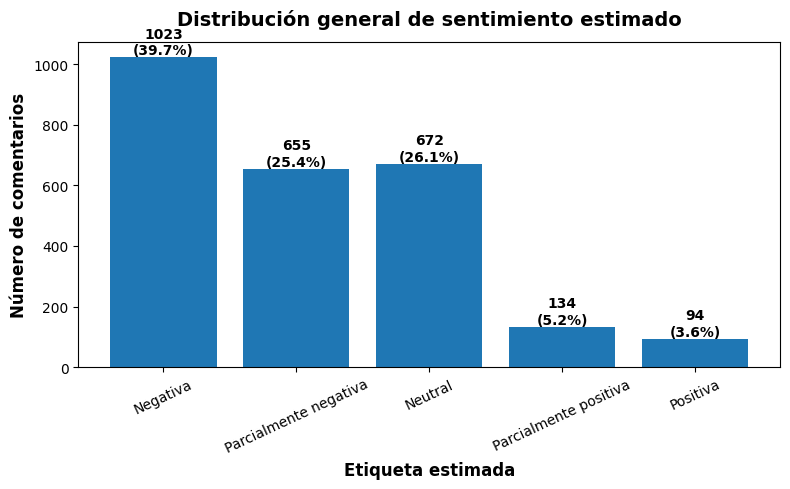

In [52]:
orden = [1, 2, 3, 4, 5]
etiquetas = {
    1: "Negativa",
    2: "Parcialmente negativa",
    3: "Neutral",
    4: "Parcialmente positiva",
    5: "Positiva"
}

conteo_etiquetas = (
    res_df["etiqueta_estimada"]
    .value_counts()
    .reindex(orden, fill_value=0)
    .rename_axis("etiqueta_estimada")
    .reset_index(name="conteo")
)
conteo_etiquetas["porcentaje"] = 100 * conteo_etiquetas["conteo"] / conteo_etiquetas["conteo"].sum()
conteo_etiquetas["sentimiento"] = conteo_etiquetas["etiqueta_estimada"].map(etiquetas)

display(conteo_etiquetas)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(
    conteo_etiquetas["sentimiento"],
    conteo_etiquetas["conteo"]
)

ax.set_title("Distribución general de sentimiento estimado", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Etiqueta estimada", fontsize=12, fontweight="bold")
ax.set_ylabel("Número de comentarios", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=25)

for barra, pct in zip(barras, conteo_etiquetas["porcentaje"]):
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f"{altura:.0f}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
guardar_figura("01_distribucion_general_etiquetas.png")
plt.show()


## 8. Postura social agregada: negativa, neutral y positiva

Para la conclusión del proyecto conviene agrupar la escala ordinal. Esta vista responde de forma más directa si predomina una lectura de rechazo, neutralidad o aprobación.


,postura,conteo,porcentaje
0,Negativa,1678,65.089216
1,Neutral,672,26.066718
2,Positiva,228,8.844065


Gráfica guardada en: c:\Users\nicte\Documents\LLM_PROJECT_1\data\resultados\graficas_escalamiento\02_postura_social_agregada.png


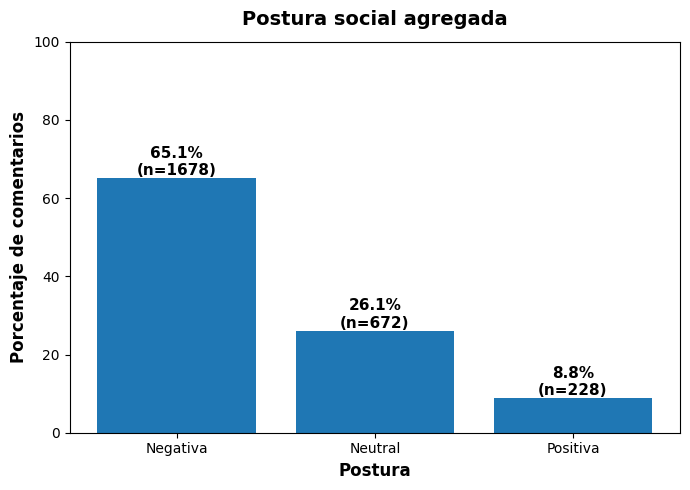

In [55]:
conteo_postura = (
    res_df["postura"]
    .value_counts()
    .reindex(orden_postura, fill_value=0)
    .rename_axis("postura")
    .reset_index(name="conteo")
)
conteo_postura["porcentaje"] = 100 * conteo_postura["conteo"] / conteo_postura["conteo"].sum()

display(conteo_postura)

fig, ax = plt.subplots(figsize=(7, 5))
barras = ax.bar(conteo_postura["postura"], conteo_postura["porcentaje"])

ax.set_title("Postura social agregada", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Postura", fontsize=12, fontweight="bold")
ax.set_ylabel("Porcentaje de comentarios", fontsize=12, fontweight="bold")
ax.set_ylim(0, max(100, conteo_postura["porcentaje"].max() + 10))

for barra, pct, n in zip(barras, conteo_postura["porcentaje"], conteo_postura["conteo"]):
    ax.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height(),
        f"{pct:.1f}%\n(n={n})",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
guardar_figura("02_postura_social_agregada.png")
plt.show()


## 9. Promedio de sentimiento por categoría

El promedio conserva la escala ordinal 1-5. Valores más cercanos a 1 indican una conversación más negativa; valores más cercanos a 5 indican una conversación más positiva.

Esta métrica no reemplaza la distribución completa, pero permite ordenar las categorías de menor a mayor aceptación estimada.


,categoria,n,sentimiento_promedio,confianza_promedio,pct_negativa,pct_neutral,pct_positiva,balance_postura
1,seguridad,971,1.869,0.630,72.297,18.950,8.754,-63.543
2,turismo,782,2.096,0.604,60.614,30.818,8.568,-52.046
0,infraestructura,825,2.304,0.539,60.848,29.939,9.212,-51.636


Gráfica guardada en: c:\Users\nicte\Documents\LLM_PROJECT_1\data\resultados\graficas_escalamiento\04_sentimiento_promedio_por_categoria.png


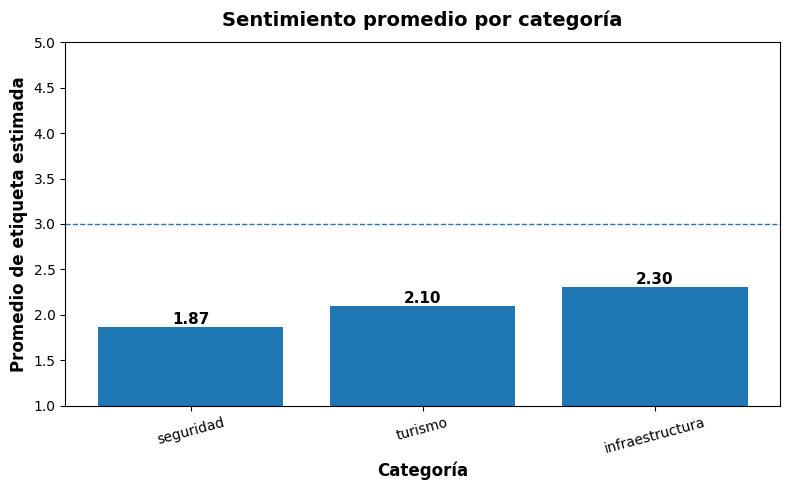

In [56]:
resumen_categoria = (
    res_df.groupby("categoria")
    .agg(
        n=("comentario", "count"),
        sentimiento_promedio=("etiqueta_estimada", "mean"),
        confianza_promedio=("confianza", "mean")
    )
    .reset_index()
)

postura_pct = pd.crosstab(
    res_df["categoria"],
    res_df["postura"],
    normalize="index"
).reindex(columns=orden_postura, fill_value=0) * 100

postura_pct = postura_pct.reset_index().rename(columns={
    "Negativa": "pct_negativa",
    "Neutral": "pct_neutral",
    "Positiva": "pct_positiva"
})

resumen_categoria = resumen_categoria.merge(postura_pct, on="categoria", how="left")
resumen_categoria["balance_postura"] = resumen_categoria["pct_positiva"] - resumen_categoria["pct_negativa"]
resumen_categoria = resumen_categoria.sort_values("sentimiento_promedio")

display(resumen_categoria.round(3))

resumen_categoria.to_csv(
    GRAFICAS_PATH / "resumen_categoria_escalamiento.csv",
    index=False,
    encoding="utf-8-sig"
)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(resumen_categoria["categoria"], resumen_categoria["sentimiento_promedio"])

ax.axhline(3, linestyle="--", linewidth=1)
ax.set_title("Sentimiento promedio por categoría", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Categoría", fontsize=12, fontweight="bold")
ax.set_ylabel("Promedio de etiqueta estimada", fontsize=12, fontweight="bold")
ax.set_ylim(1, 5)
ax.tick_params(axis="x", rotation=15)

for barra, valor in zip(barras, resumen_categoria["sentimiento_promedio"]):
    ax.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height(),
        f"{valor:.2f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
guardar_figura("04_sentimiento_promedio_por_categoria.png")
plt.show()


## 10. Confianza del modelo

La confianza ayuda a distinguir predicciones más claras de predicciones más inciertas. Si una categoría tiene baja confianza promedio, conviene revisar ejemplos manualmente antes de sostener conclusiones fuertes.


,postura,n,confianza_promedio,confianza_mediana
0,Negativa,1678,0.651,0.596
1,Neutral,672,0.465,0.460
2,Positiva,228,0.549,0.501


Gráfica guardada en: c:\Users\nicte\Documents\LLM_PROJECT_1\data\resultados\graficas_escalamiento\06_confianza_por_postura.png


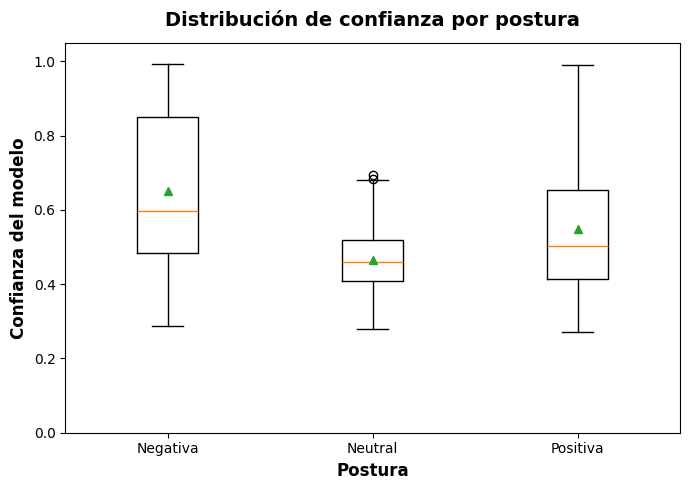

In [57]:
confianza_por_postura = (
    res_df.groupby("postura")
    .agg(
        n=("comentario", "count"),
        confianza_promedio=("confianza", "mean"),
        confianza_mediana=("confianza", "median")
    )
    .reindex(orden_postura)
    .reset_index()
)

display(confianza_por_postura.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
valores_box = [
    res_df.loc[res_df["postura"] == postura, "confianza"].dropna().values
    for postura in orden_postura
]

ax.boxplot(valores_box, labels=orden_postura, showmeans=True)
ax.set_title("Distribución de confianza por postura", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Postura", fontsize=12, fontweight="bold")
ax.set_ylabel("Confianza del modelo", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.05)

plt.tight_layout()
guardar_figura("06_confianza_por_postura.png")
plt.show()
